## 5. Modelado y evaluación

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings

from pathlib import Path
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, Model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

import optuna


# Paths
X_train_in = Path("../data/modeling/supervised/X_train.parquet")
X_test_in = Path("../data/modeling/supervised/X_test.parquet")
y_train_in = Path("../data/modeling/supervised/y_train.parquet")
y_test_in = Path("../data/modeling/supervised/y_test.parquet")

X_train_N_in = Path("../data/modeling/unsupervised/X_train_N.parquet")
X_test_N_in = Path("../data/modeling/unsupervised/X_test_N.parquet")
y_test_N_in = Path("../data/modeling/unsupervised/y_test_N.parquet")

# Add src/ to Python path
sys.path.append(str(Path("../src").resolve()))

# My own functions
from model.evaluation import print_feature_importance, get_defensive_threshold, evaluate_binary, evaluate_multiclass
from model.tunning import tune_xgboost, tune_rf, tune_if, tune_autoencoder, tune_xgboost_multiclass, tune_rf_multiclass

I0000 00:00:1781352092.182015   35129 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#

#### 1) Revisión general

Cargo los diferentes conjuntos preparados para usar en los diferentes modelos.

In [2]:
X_train = pd.read_parquet(X_train_in)
X_test = pd.read_parquet(X_test_in)
y_train = pd.read_parquet(y_train_in)
y_test = pd.read_parquet(y_test_in)

X_train_N = pd.read_parquet(X_train_N_in)
X_test_N = pd.read_parquet(X_test_N_in)
y_test_N = pd.read_parquet(y_test_N_in)

Necesito los nombre de las columnas para luego en laimportancia de las variables:

In [3]:
columns = X_train.columns
columns_N = X_train_N.columns

Soluciono un par de errores de tipo pd a np: 

In [4]:
y_train = y_train.squeeze().to_numpy()
y_test = y_test.squeeze().to_numpy()
X_train = X_train.squeeze().to_numpy()
X_test = X_test.squeeze().to_numpy()

In [5]:
X_train_N = X_train_N.squeeze().to_numpy()
X_test_N = X_test_N.squeeze().to_numpy()
y_test_N = y_test_N.squeeze().to_numpy()

#

#### 2) Modelos Supervisados

In [6]:
# I wanna avoid bias (ensure X_train was not exposed to target leakage during tuning)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

**XGBoost**

In [7]:
# Weights adjustment
neg, pos = np.bincount(y_tr)
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 4.08257578037988


In [8]:
warnings.filterwarnings("ignore") # Omit warning in memory usage
best_params = tune_xgboost(X_tr, y_tr, scale_pos_weight, n_trials=10)
print(best_params)

  0%|          | 0/10 [00:00<?, ?it/s]

{'learning_rate': 0.030710573677773714, 'max_depth': 8, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 2, 'gamma': 0.003775887545682684, 'alpha': 3.3323645788192616e-08, 'reg_lambda': 2.9154431891537547}


In [9]:
# --- XGBOOST FITTING ---
base_model = XGBClassifier(
    **best_params, # Unpack the optimized tuning parameters
    n_estimators=2000,          # Expanded budget to let the low learning_rate fully converge
    early_stopping_rounds=100,  # Generous lookahead window to find the absolute global minimum
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    device="cuda",              # Hardware acceleration
    eval_metric="logloss",
    verbosity=0,
    random_state=42,
    n_jobs=-1,
)

# Fitting the model
base_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-logloss:0.66876
[50]	validation_0-logloss:0.21311
[100]	validation_0-logloss:0.13840
[150]	validation_0-logloss:0.12127
[200]	validation_0-logloss:0.11627
[250]	validation_0-logloss:0.11348
[300]	validation_0-logloss:0.11134
[350]	validation_0-logloss:0.10969
[400]	validation_0-logloss:0.10833
[450]	validation_0-logloss:0.10720
[500]	validation_0-logloss:0.10614
[550]	validation_0-logloss:0.10534
[600]	validation_0-logloss:0.10456
[650]	validation_0-logloss:0.10399
[700]	validation_0-logloss:0.10349
[750]	validation_0-logloss:0.10298
[800]	validation_0-logloss:0.10252
[850]	validation_0-logloss:0.10206
[900]	validation_0-logloss:0.10172
[950]	validation_0-logloss:0.10130
[1000]	validation_0-logloss:0.10093
[1050]	validation_0-logloss:0.10058
[1100]	validation_0-logloss:0.10030
[1150]	validation_0-logloss:0.10001
[1200]	validation_0-logloss:0.09976
[1250]	validation_0-logloss:0.09949
[1300]	validation_0-logloss:0.09924
[1350]	validation_0-logloss:0.09898
[1400]	validati

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8394633936788146
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

Optimal Threshold (Validation): 0.467292

Evaluating with Pre-determined Threshold: 0.467292

=== RAW CONFUSION MATRIX ===
[[330637   8432]
 [  6732  76320]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98    339069
      Attack       0.90      0.92      0.91     83052

    accuracy                           0.96    422121
   macro avg       0.94      0.95      0.94    422121
weighted avg       0.96      0.96      0.96    422121



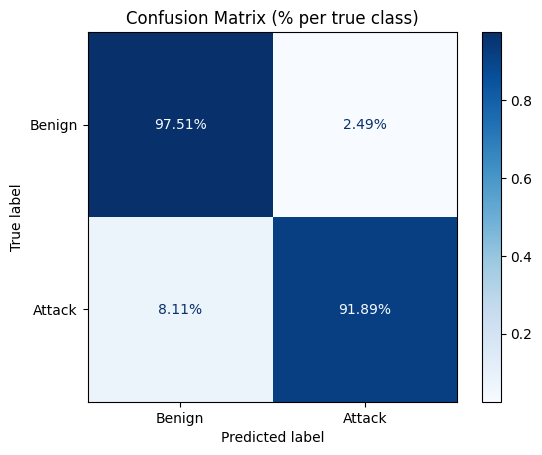

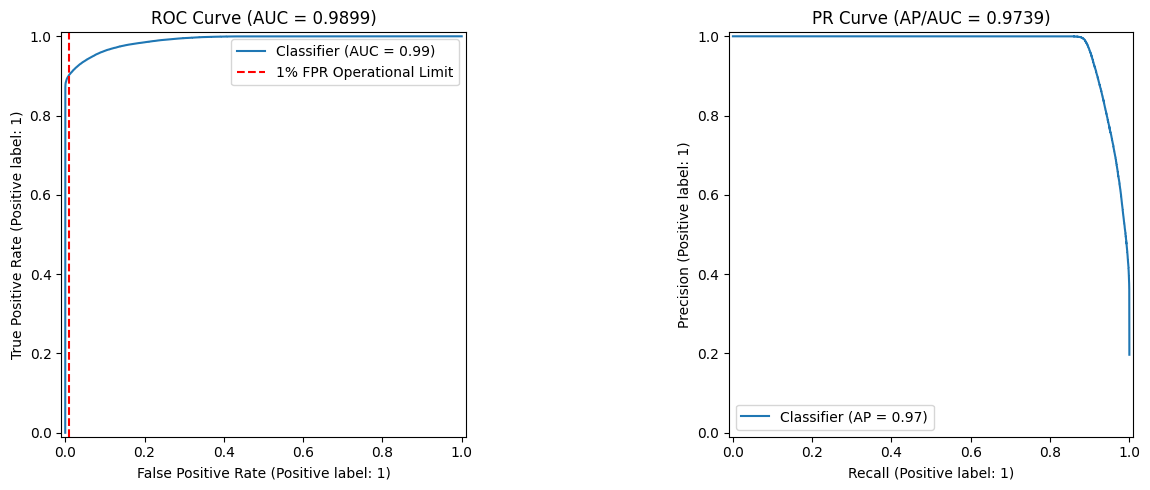

In [10]:
# 1. VALIDATION predictions to isolate the decision threshold safely
val_scores = base_model.get_booster().inplace_predict(
    X_val, 
    predict_type="probability", 
    iteration_range=(0, base_model.best_iteration + 1)
)

# Optimize threshold strictly on validation distributions to avoid test data leakage
best_threshold = get_defensive_threshold(val_scores, y_val, beta=2)
print(f"Optimal Threshold (Validation): {best_threshold:.6f}")


# 2. TEST predictions for final performance validation
test_scores = base_model.get_booster().inplace_predict(
    X_test, 
    predict_type="probability", 
    iteration_range=(0, base_model.best_iteration + 1)
)

# 3. Final blind evaluation (Strict separation maintained)
evaluate_binary(test_scores, y_test, best_threshold)

In [11]:
# FEATURE IMPORTANCE 
print_feature_importance(columns, base_model.feature_importances_)


Top 20 Most Important Features:
                      Feature  Importance_Score
             Fwd Seg Size Min          0.135298
            Init Bwd Win Byts          0.135091
                  Pkt Len Max          0.100552
            Init Fwd Win Byts          0.079683
             Dst Port Cat_web          0.061173
              Bwd Pkt Len Std          0.059863
                 ECE Flag Cnt          0.040747
              Bwd Pkt Len Max          0.034975
                 RST Flag Cnt          0.034443
               CWE Flag Count          0.033715
              Fwd Pkt Len Max          0.028570
      Dst Port Cat_registered          0.017174
                Fwd URG Flags          0.014366
Dst Port Cat_well_known_other          0.013592
                 SYN Flag Cnt          0.013258
       Dst Port Cat_ephemeral          0.013117
                 PSH Flag Cnt          0.012487
             Dst Port Cat_ssh          0.012255
              Fwd Pkt Len Std          0.011295
       

**Random Forest**

In [12]:
best_params = tune_rf(X_tr, y_tr, n_trials=5)
print(best_params)

  0%|          | 0/5 [00:00<?, ?it/s]

{'n_estimators': 119, 'max_depth': 20, 'max_features': 0.49279757672456204, 'min_samples_split': 10, 'min_samples_leaf': 2, 'criterion': 'gini'}


In [13]:
rf_model = RandomForestClassifier(
    **best_params,
    class_weight="balanced",  # Critical for our dataset with class imbalance
    n_jobs=-1,                # Spreads the final tree building across all CPU cores
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",119
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.49279757672456204
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signa

Optimal Threshold (Validation): 0.388617

Evaluating with Pre-determined Threshold: 0.388617

=== RAW CONFUSION MATRIX ===
[[329711   9358]
 [  6469  76583]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.98    339069
      Attack       0.89      0.92      0.91     83052

    accuracy                           0.96    422121
   macro avg       0.94      0.95      0.94    422121
weighted avg       0.96      0.96      0.96    422121



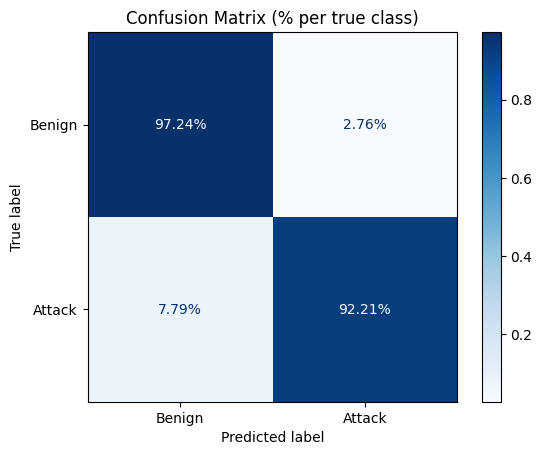

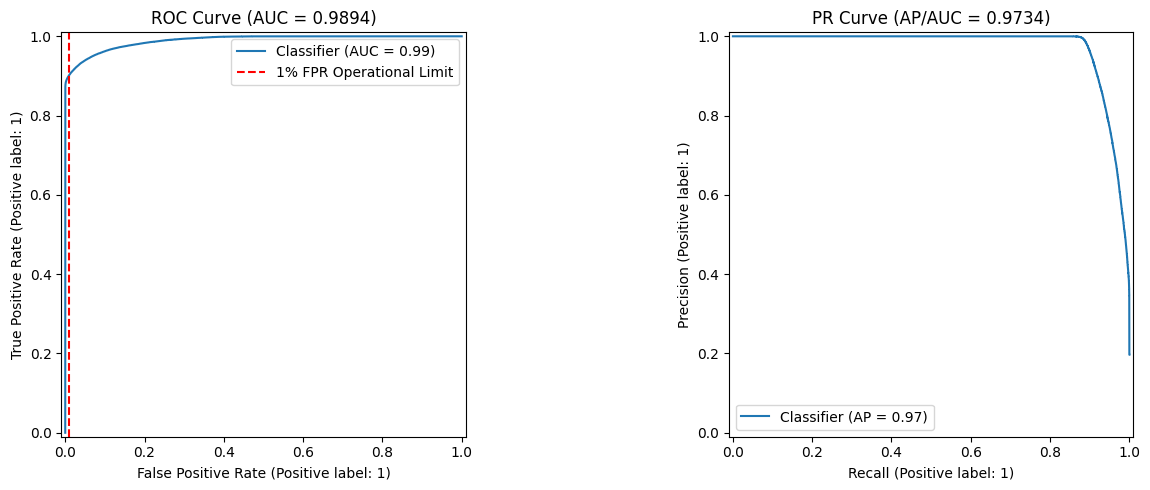

In [14]:
# 1. VALIDATION probabilities to find the threshold safely
val_scores = rf_model.predict_proba(X_val)[:, 1]
best_threshold = get_defensive_threshold(val_scores, y_val, beta=2)
print(f"Optimal Threshold (Validation): {best_threshold:.6f}")

# 2. TEST probabilities for final evaluation
test_scores = rf_model.predict_proba(X_test)[:, 1]

# 3. Evaluate blindly (Zero Leakage)
evaluate_binary(test_scores, y_test, best_threshold)

In [15]:
# FEATURE IMPORTANCE 
print_feature_importance(columns, rf_model.feature_importances_)


Top 20 Most Important Features:
               Feature  Importance_Score
     Init Fwd Win Byts          0.309598
     Init Bwd Win Byts          0.148069
       Bwd Pkt Len Std          0.077501
       Fwd Pkt Len Max          0.060644
      Fwd Seg Size Min          0.053205
       Bwd Pkt Len Max          0.038938
           Pkt Len Max          0.037971
            Bwd Pkts/s          0.029080
       Fwd Pkt Len Std          0.028853
Dst Port Cat_ephemeral          0.025335
            Fwd Pkts/s          0.020794
           Flow Pkts/s          0.018463
         Flow Duration          0.016878
      Fwd Pkt Len Mean          0.011040
           Flow Byts/s          0.010159
      Bwd Pkt Len Mean          0.009453
      Dst Port Cat_web          0.008929
       repetition_flow          0.008383
           Bwd IAT Min          0.007666
          Tot Bwd Pkts          0.007468


#

#### 3) Modelos No Supervisados

In [7]:
# I wanna avoid bias when we evaluate the models
X_val_N, X_test_final, y_val_N, y_test_final = train_test_split(
    X_test_N,
    y_test_N,
    test_size=0.5,
    stratify=y_test_N,
    random_state=42
)

**Isolation Forest**

In [8]:
best_params = tune_if(X_train_N, n_trials=30)
print(best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

{'n_estimators': 230, 'max_samples': 0.9974823353282927, 'max_features': 0.7585006738258346, 'contamination': 0.14942239710337815}


In [9]:
if_model = IsolationForest(
    **best_params,
    random_state=42,
    n_jobs=-1
)

# TRAIN (unsupervised: only X_train)
if_model.fit(X_train_N)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",230
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",0.9974823353282927
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.14942239710337815
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",0.7585006738258346
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


Optimal Anomaly Threshold (Validation): -0.015445

Evaluating with Pre-determined Threshold: -0.015445

=== RAW CONFUSION MATRIX ===
[[122709  46826]
 [ 16535 191096]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.88      0.72      0.79    169535
      Attack       0.80      0.92      0.86    207631

    accuracy                           0.83    377166
   macro avg       0.84      0.82      0.83    377166
weighted avg       0.84      0.83      0.83    377166



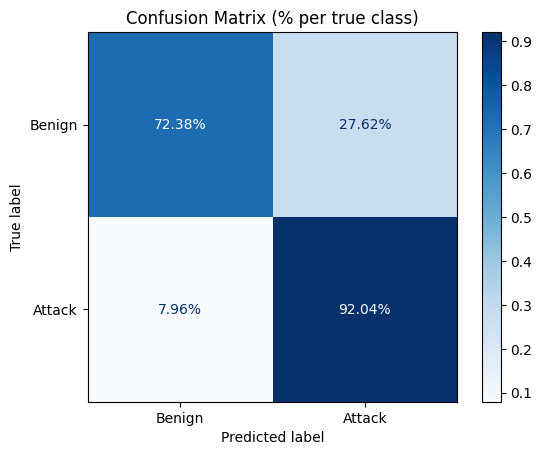

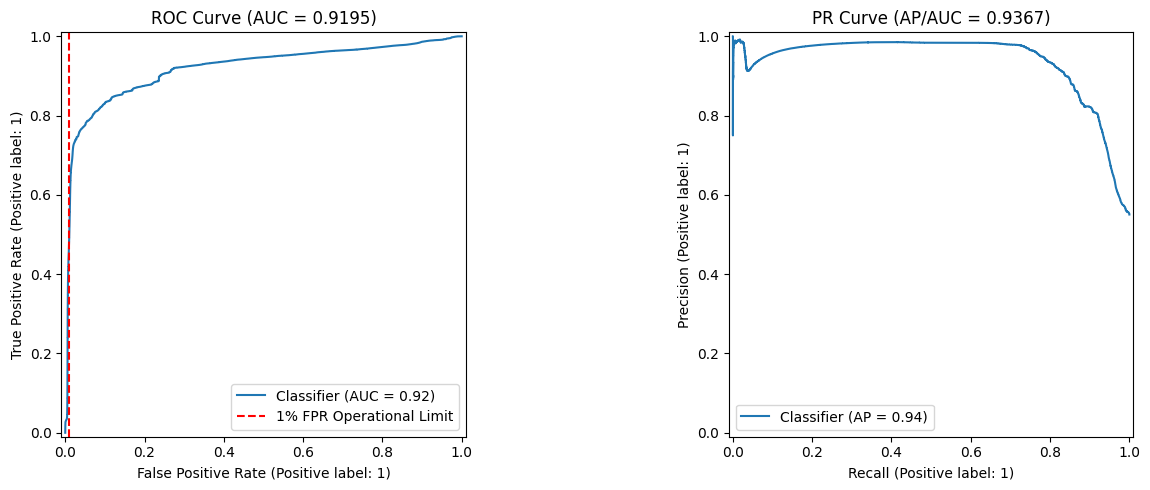

In [35]:
# 1. Get VALIDATION scores to find the threshold safely
val_scores = -if_model.decision_function(X_val_N)
best_threshold = get_defensive_threshold(val_scores, y_val_N, beta=1)
print(f"Optimal Anomaly Threshold (Validation): {best_threshold:.6f}")

# 2. Get TEST scores using the untouched final test split
final_test_scores = -if_model.decision_function(X_test_final)

# 3. Evaluate blindly (Zero Leakage) using your unsupervised function
evaluate_binary(final_test_scores, y_test_final, best_threshold)

In [11]:
# 1. Segment validation data to find the clean benign baseline
is_val_benign = val_scores < best_threshold
X_val_benign = X_val_N[is_val_benign]

benign_medians = np.median(X_val_benign, axis=0)
benign_mads = np.median(np.abs(X_val_benign - benign_medians), axis=0) + 1e-6

# 2. Calculate Absolute Deviation safely on the untouched final test split
abs_deviation_per_feature = np.median(np.abs(X_test_final - benign_medians), axis=0) / benign_mads

# 3. Print the leak-free feature importance profiles
print_feature_importance(columns_N, abs_deviation_per_feature)


Top 20 Most Important Features:
             Feature  Importance_Score
       Down/Up Ratio    1000000.000000
     log_Bwd IAT Std     611966.687500
     log_Bwd IAT Min          4.913838
   Init Fwd Win Byts          2.281336
    log_Tot Bwd Pkts          1.409416
 log_Bwd Pkt Len Max          1.248354
log_Bwd Pkt Len Mean          1.096071
     log_Pkt Len Std          1.002060
     log_Pkt Len Var          1.001390
     log_Pkt Len Max          0.999998
     log_Bwd IAT Max          0.999998
     log_Bwd IAT Tot          0.999998
   Init Bwd Win Byts          0.992729
    log_Pkt Len Mean          0.990925
      log_Bwd Pkts/s          0.976814
     log_Flow Byts/s          0.894956
 log_TotLen Fwd Pkts          0.865068
    log_Bwd IAT Mean          0.834104
log_Fwd Pkt Len Mean          0.819957
 log_Bwd Pkt Len Std          0.815227


**Autoencoder**

In [12]:
best = tune_autoencoder(X_train_N, n_trials=30)
print(best)

  0%|          | 0/30 [00:00<?, ?it/s]

W0000 00:00:1781352995.937961   35129 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


{'latent_dim': 14, 'lr': 0.004123206532618728, 'batch_size': 128, 'n1': 94, 'n2': 35, 'activation': 'leaky_relu', 'dropout': 0.10621088666940683, 'reg_l2': 1.1527987128232402e-06, 'contamination': 0.14563692856348917}


In [13]:
# --- PREVENT VALIDATION SPLIT LEAKAGE ---
# Explicitly shuffle the matrix copy to break temporal/group ordering 
# before Keras slices the final 15% validation block.
indices = np.arange(X_train_N.shape[0])
np.random.seed(42)  # Set seed for reproducible validation selection
np.random.shuffle(indices)
X_train_shuffled = X_train_N[indices]

# Clear old remnants from the GPU/RAM before launching the final intensive run
tf.keras.backend.clear_session()

# Safely extract regularizer parameters selected during optimization
l2_val = best.get("reg_l2", 1e-4)
reg = tf.keras.regularizers.l2(l2_val)
act_fn = best["activation"] 
dropout_rate = best.get("dropout", 0.0)

# --- Architecture ---
input_dim = X_train_shuffled.shape[1]
inp = layers.Input(shape=(input_dim,), name="Input_Layer")

# Encoder: Compresses features step-by-step using optimized activations
x = layers.Dense(best["n1"], activation=act_fn, kernel_regularizer=reg, name="Encoder_Dense_1")(inp)
if dropout_rate > 0: 
    x = layers.Dropout(dropout_rate, name="Encoder_Dropout_1")(x)

x = layers.Dense(best["n2"], activation=act_fn, kernel_regularizer=reg, name="Encoder_Dense_2")(x)
if dropout_rate > 0: 
    x = layers.Dropout(dropout_rate, name="Encoder_Dropout_2")(x)

# Bottleneck: Linear activation perfectly preserves native distributions from Scalers
latent = layers.Dense(best["latent_dim"], activation="linear", name="Latent_Bottleneck")(x)  

# Decoder: Reconstructs representation (No dropout here to preserve mapping clarity)
x = layers.Dense(best["n2"], activation=act_fn, kernel_regularizer=reg, name="Decoder_Dense_1")(latent)
x = layers.Dense(best["n1"], activation=act_fn, kernel_regularizer=reg, name="Decoder_Dense_2")(x)
out = layers.Dense(input_dim, activation="linear", name="Output_Reconstruction")(x)

# --- Compile & Train ---
autoencoder = Model(inp, out, name="CIC_IDS2018_Unsupervised_Autoencoder")

# Enabling amsgrad=True tracks the maximum historical gradient bounds for skewed network metrics
optimizer = tf.keras.optimizers.Adam(learning_rate=best["lr"], amsgrad=True)
autoencoder.compile(optimizer=optimizer, loss="mae")

# Increased patience window slightly so the final run can comfortably converge
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", 
        patience=15,               # Slightly larger patience window for final deep convergence
        restore_best_weights=True  # Automatically rolls back weights to the global minimum
    )
]

# Train across your full available feature grid array
history = autoencoder.fit(
    X_train_shuffled, X_train_shuffled,
    epochs=200,                    # Expanded ceiling; EarlyStopping guarantees safety
    batch_size=best["batch_size"],
    shuffle=True,                  # Shuffles training batches every epoch
    validation_split=0.15,         # Now safe from temporal data bias due to explicit pre-shuffle
    verbose=1,
    callbacks=callbacks
)

Epoch 1/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - loss: 0.0771 - val_loss: 0.0451
Epoch 2/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0524 - val_loss: 0.0380
Epoch 3/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0483 - val_loss: 0.0369
Epoch 4/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0459 - val_loss: 0.0344
Epoch 5/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0442 - val_loss: 0.0332
Epoch 6/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0430 - val_loss: 0.0338
Epoch 7/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0422 - val_loss: 0.0326
Epoch 8/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0415 - val_loss: 0.0337
Epoch 9/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0410 - val_loss: 0.0339
Epoch 10/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0405 - val_loss: 0.0311
Epoch 11/200
9007/9007 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - loss: 0.0403 - val_loss: 0.0301
Epoch 12

Optimal Anomaly Threshold (Validation): 0.065050

Evaluating with Pre-determined Threshold: 0.065050

=== RAW CONFUSION MATRIX ===
[[151034  18501]
 [ 32975 174656]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.82      0.89      0.85    169535
      Attack       0.90      0.84      0.87    207631

    accuracy                           0.86    377166
   macro avg       0.86      0.87      0.86    377166
weighted avg       0.87      0.86      0.86    377166



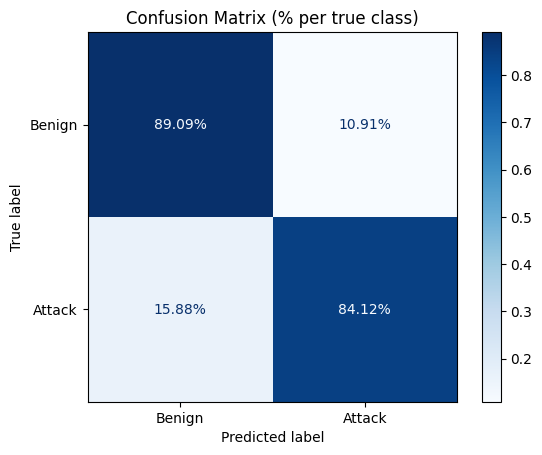

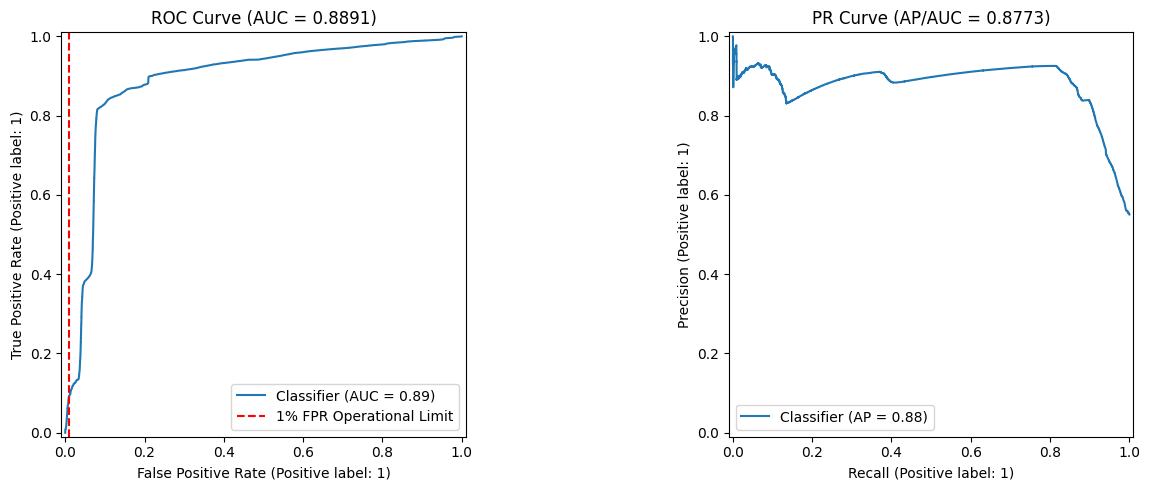

In [36]:
# 1. VALIDATION scores to find the threshold safely
val_recon = autoencoder.predict(X_val_N, verbose=0)
val_scores = np.mean(np.abs(X_val_N - val_recon), axis=1)
best_threshold = get_defensive_threshold(val_scores, y_val_N, beta=1)
print(f"Optimal Anomaly Threshold (Validation): {best_threshold:.6f}")

# 2. TEST scores using the untouched final test split
final_test_recon = autoencoder.predict(X_test_final, verbose=0)
final_test_scores = np.mean(np.abs(X_test_final - final_test_recon), axis=1)

# 3. Evaluate blindly (Zero Leakage) using your unsupervised function
evaluate_binary(final_test_scores, y_test_final, best_threshold)

In [15]:
# Calculate the Mean Absolute Error (MAE) for each column individually
# (This averages the error across all rows for each feature index)
mae_per_feature = np.mean(np.abs(X_test_final - final_test_recon), axis=0)
# Important features for detecting anomalies
print_feature_importance(columns_N, mae_per_feature)


Top 20 Most Important Features:
                Feature  Importance_Score
        repetition_flow          0.619789
      Init Fwd Win Byts          0.357235
       Fwd Seg Size Min          0.221830
           ECE Flag Cnt          0.173004
           RST Flag Cnt          0.170178
       Dst Port Cat_ssh          0.127114
      log_Flow Duration          0.122186
        log_Bwd IAT Min          0.120009
        log_Bwd IAT Std          0.119194
       Dst Port Cat_web          0.115765
          Down/Up Ratio          0.095501
 Dst Port Cat_ephemeral          0.093155
Dst Port Cat_registered          0.093050
    log_Bwd Pkt Len Max          0.089711
   log_Fwd Pkt Len Mean          0.088633
    log_Fwd Pkt Len Max          0.082614
   log_Bwd Pkt Len Mean          0.074932
       log_Tot Bwd Pkts          0.074764
      Init Bwd Win Byts          0.066991
         log_Active Min          0.066909


#

#### 4) Modelos Supervisados Multiclase

**XGBoost**

In [16]:
warnings.filterwarnings("ignore") # Omit warning in memory usage
best_params = tune_xgboost_multiclass(X_tr, y_tr, n_trials=15)
print(best_params)

  0%|          | 0/15 [00:00<?, ?it/s]

{'learning_rate': 0.06876892882459189, 'max_depth': 5, 'subsample': 0.9358778633152698, 'colsample_bytree': 0.8103839640611089, 'min_child_weight': 2}


In [17]:
# Calculate balanced class weights based ONLY on the final training split (y_tr)
classes = np.unique(y_tr)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
w_dict = dict(zip(classes, weights))
final_sample_weights = np.array([w_dict[cls] for cls in y_tr])

base_model = XGBClassifier(
    **best_params,
    tree_method="hist",
    device="cuda",
    eval_metric="mlogloss",      # mlogloss for multiclass
    early_stopping_rounds=100,  # critical for preventing overfitting with high estimators
    verbosity=0,                # eliminates device mismatch warning logs
    random_state=42,
    n_jobs=-1,
    n_estimators=2000           # important for early stopping stability
)

# Fitting the model
base_model.fit(
    X_tr,
    y_tr,
    sample_weight=final_sample_weights, # <-- injected multiclass weights
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-mlogloss:1.91254
[50]	validation_0-mlogloss:0.48614
[100]	validation_0-mlogloss:0.38424
[150]	validation_0-mlogloss:0.35319
[200]	validation_0-mlogloss:0.34046
[250]	validation_0-mlogloss:0.33181
[300]	validation_0-mlogloss:0.32617
[350]	validation_0-mlogloss:0.32125
[400]	validation_0-mlogloss:0.31710
[450]	validation_0-mlogloss:0.31348
[500]	validation_0-mlogloss:0.31038
[550]	validation_0-mlogloss:0.30771
[600]	validation_0-mlogloss:0.30518
[650]	validation_0-mlogloss:0.30281
[700]	validation_0-mlogloss:0.30100
[750]	validation_0-mlogloss:0.29906
[800]	validation_0-mlogloss:0.29729
[850]	validation_0-mlogloss:0.29558
[900]	validation_0-mlogloss:0.29390
[950]	validation_0-mlogloss:0.29249
[1000]	validation_0-mlogloss:0.29090
[1050]	validation_0-mlogloss:0.28950
[1100]	validation_0-mlogloss:0.28807
[1150]	validation_0-mlogloss:0.28694
[1200]	validation_0-mlogloss:0.28572
[1250]	validation_0-mlogloss:0.28475
[1300]	validation_0-mlogloss:0.28350
[1350]	validation_0-mlog

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8103839640611089
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 


=== CONFUSION MATRIX ===
[[276965      0      0      5      1      0  62095      2]
 [     0  41220      0      0      0      0      0      0]
 [     0      0    346      0      0      0      0      0]
 [     0      0      0   8278      1      0      0      0]
 [     0      0      0      0   1903      0      0      0]
 [     0      0      0      0      0     33      0      1]
 [  1504      0      0      0      0      0  10954      0]
 [     0      0      0      0      0      0      0  18813]]


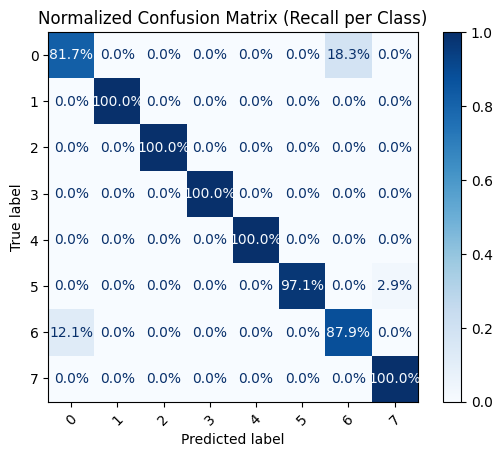


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      0.82      0.90    339068
           1       1.00      1.00      1.00     41220
           2       1.00      1.00      1.00       346
           3       1.00      1.00      1.00      8279
           4       1.00      1.00      1.00      1903
           5       1.00      0.97      0.99        34
           6       0.15      0.88      0.26     12458
           7       1.00      1.00      1.00     18813

    accuracy                           0.85    422121
   macro avg       0.89      0.96      0.89    422121
weighted avg       0.97      0.85      0.90    422121


Accuracy: 0.8493109795532561


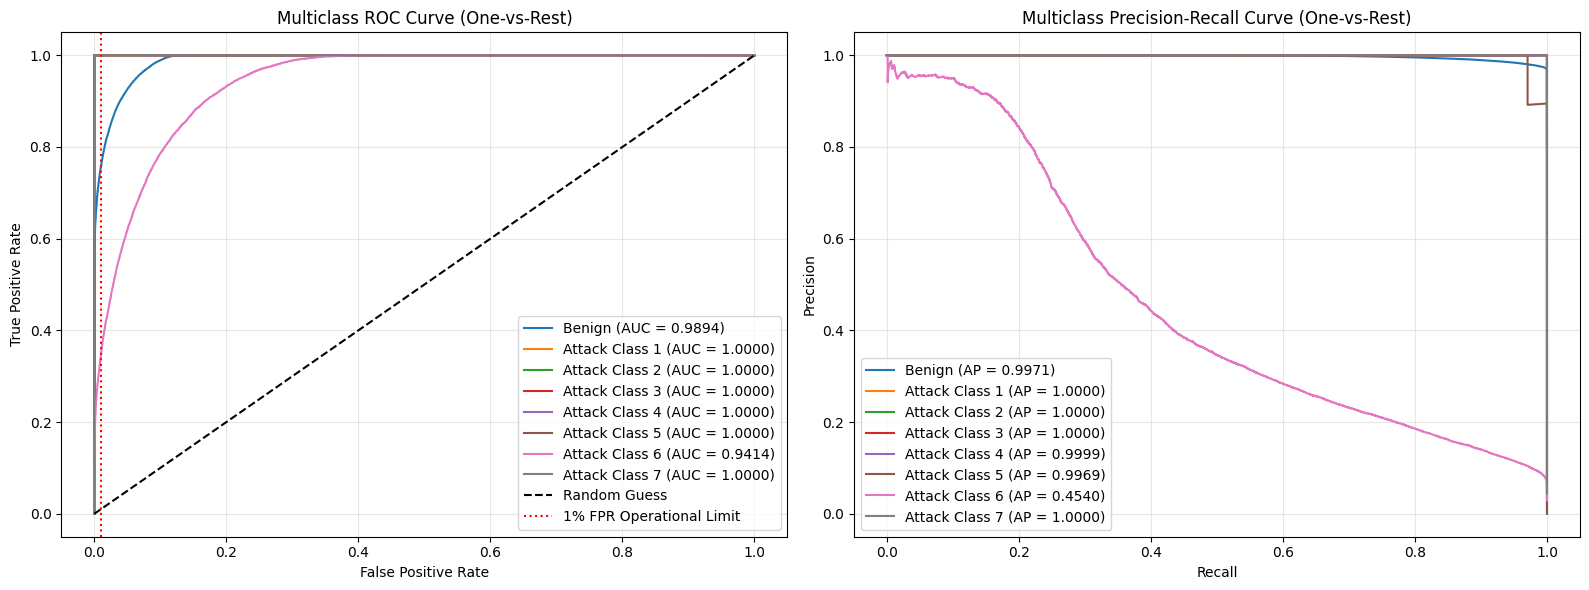

In [31]:
# EVALUATION
evaluate_multiclass(base_model, X_test, y_test)

In [19]:
# FEATURE IMPORTANCE 
print_feature_importance(columns, base_model.feature_importances_)


Top 20 Most Important Features:
                      Feature  Importance_Score
             Dst Port Cat_ssh          0.311196
             Dst Port Cat_ftp          0.222041
                 ECE Flag Cnt          0.066708
              TotLen Fwd Pkts          0.048632
             Fwd Seg Size Min          0.044350
                 Bwd IAT Mean          0.039393
             Dst Port Cat_web          0.025806
            Init Fwd Win Byts          0.017842
              Bwd Pkt Len Std          0.017436
                Fwd PSH Flags          0.016245
                  Flow Pkts/s          0.015184
                 RST Flag Cnt          0.013399
                  Bwd IAT Tot          0.013286
                 Tot Bwd Pkts          0.012878
                 SYN Flag Cnt          0.012600
                   Bwd Pkts/s          0.011542
      Dst Port Cat_registered          0.011229
                  Bwd IAT Max          0.010345
Dst Port Cat_well_known_other          0.007606
       

**Random Forest**

In [20]:
best_params = tune_rf_multiclass(X_tr, y_tr, n_trials=15)
print(best_params)

  0%|          | 0/15 [00:00<?, ?it/s]

{'n_estimators': 61, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 12}


In [21]:
rf_model = RandomForestClassifier(
    **best_params,
    max_features="sqrt",      # Safely forces rapid feature split evaluation 
    class_weight="balanced",  # Critical for our dataset with class imbalance
    n_jobs=-1,                # Spreads the final tree building across all CPU cores
    random_state=42
)

# Fitting the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",61
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",18
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",12
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


=== CONFUSION MATRIX ===
[[193303   1552      0     16     91      1 144099      6]
 [     0  41220      0      0      0      0      0      0]
 [     0      0    346      0      0      0      0      0]
 [     0      0      0   8279      0      0      0      0]
 [     0      0      0      0   1899      0      4      0]
 [     0      0      0      0      0     34      0      0]
 [   501     33      0      0      1      0  11923      0]
 [     0      0      0      0      0      0      2  18811]]


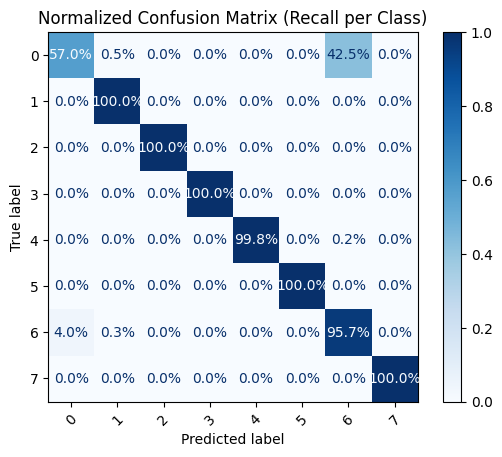


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      0.57      0.73    339068
           1       0.96      1.00      0.98     41220
           2       1.00      1.00      1.00       346
           3       1.00      1.00      1.00      8279
           4       0.95      1.00      0.98      1903
           5       0.97      1.00      0.99        34
           6       0.08      0.96      0.14     12458
           7       1.00      1.00      1.00     18813

    accuracy                           0.65    422121
   macro avg       0.87      0.94      0.85    422121
weighted avg       0.97      0.65      0.75    422121


Accuracy: 0.6534026973308601


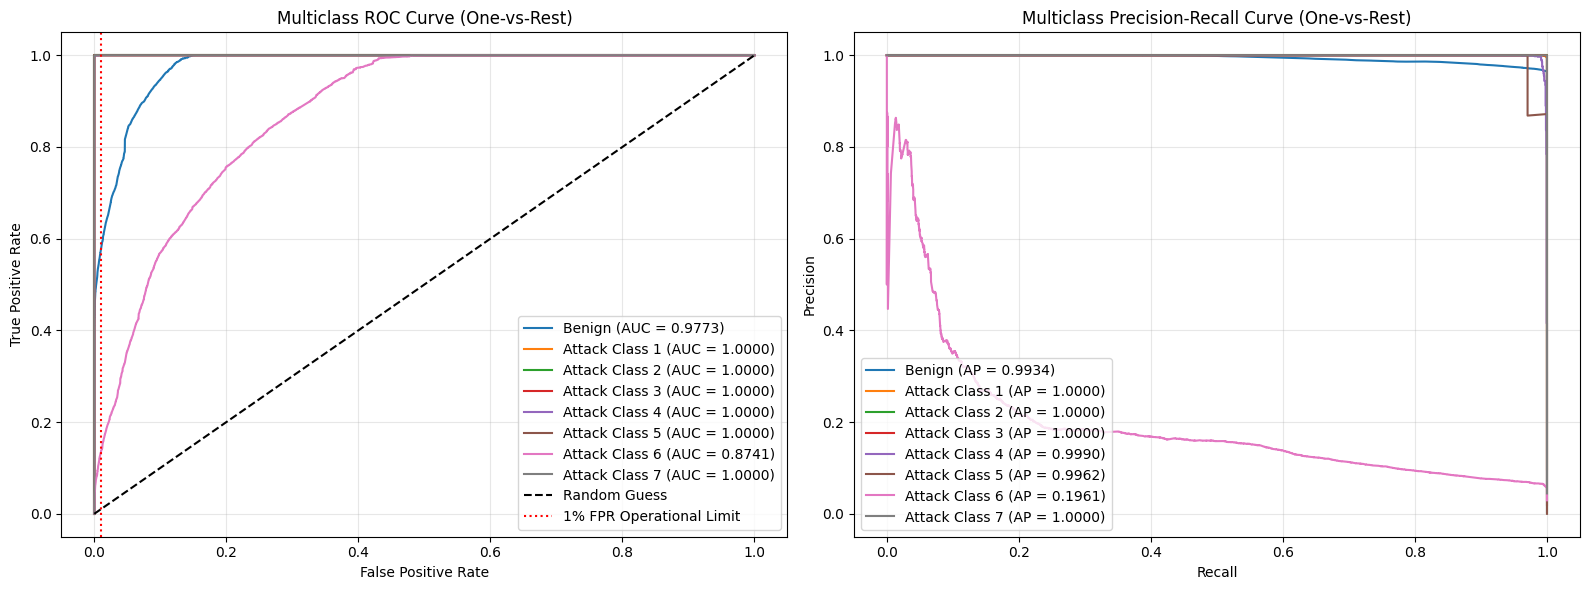

In [33]:
evaluate_multiclass(rf_model, X_test, y_test)

In [23]:
print_feature_importance(columns, rf_model.feature_importances_)


Top 20 Most Important Features:
          Feature  Importance_Score
 Fwd Seg Size Min          0.085248
  TotLen Fwd Pkts          0.075066
Init Fwd Win Byts          0.068245
    Flow Duration          0.050626
 Dst Port Cat_ssh          0.049177
 Dst Port Cat_ftp          0.045544
      Flow Pkts/s          0.043229
     Tot Bwd Pkts          0.042492
 Dst Port Cat_web          0.041418
       Bwd Pkts/s          0.039305
       Fwd Pkts/s          0.038739
      Bwd IAT Max          0.033997
      Pkt Len Min          0.027439
  Bwd Pkt Len Max          0.026548
      Pkt Len Max          0.026046
  Fwd Pkt Len Max          0.023030
      Bwd IAT Min          0.022484
     Bwd IAT Mean          0.022137
Init Bwd Win Byts          0.020870
 Bwd Pkt Len Mean          0.019765
